# A wide range transmission spectrum using ExoMolOP CKD opacity

[ExoMolOP](https://arxiv.org/abs/2009.00687) provides the CKD h5 data through [ExoMol website](https://www.exomol.com). The precomputing opacity is very handy to compute wide low resolution spectra. This tutorial shows how to compute a transmission spectrum using `OpaCKD` from the external opacity source, ExoMolOP. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jax import config

# ExoJAX imports
from exojax.utils.grids import wavenumber_grid
from exojax.opacity import OpaCKD
from exojax.rt import ArtTransPure

# Enable 64-bit precision for accurate calculations
config.update("jax_enable_x64", True)

art = ArtTransPure(
    pressure_top=1.0e-8,
    pressure_btm=1.0e2,
    nlayer=50,  # Fewer layers for transmission calculations
    integration="simpson"  # Simpson integration for better accuracy
)

# Create atmospheric profiles
Tarr = np.linspace(1000.0, 1500.0, 50)  # Temperature profile
mmr_arr = np.full(50, 0.1)  # Constant H2O mixing ratio
mean_molecular_weight = np.full(50, 2.33)  # Mean molecular weight (H2-dominated)

# Planetary parameters (Jupiter-like)
radius_btm = 6.9e9  # Planet radius at bottom of atmosphere (cm)
gravity = 2478.57   # Surface gravity (cm/s²)


integration:  simpson
Simpson integration, uses the chord optical depth at the lower boundary and midppoint of the layers.


/home/kawahara/exojax/src/exojax/rt/common.py:40: UserWarning: nu_grid is not given. specify nu_grid when using 'run' 
  warnings.warn(


In [2]:
nus, wav, res = wavenumber_grid(22900, 24000, 1000, unit="AA", xsmode="premodit")
opa = OpaCKD.from_external("exomolop","12C-16O__Li2015.R1000_0.3-50mu.ktable.petitRADTRANS.h5")

/home/kawahara/exojax/src/exojax/utils/grids.py:85: UserWarning: Both input wavelength and output wavenumber are in ascending order.
  warnings.warn(
/home/kawahara/exojax/src/exojax/utils/grids.py:249: UserWarning: Resolution may be too small. R=21292.957946075738
  warnings.warn("Resolution may be too small. R=" + str(resolution), UserWarning)


xsmode =  premodit
xsmode assumes ESLOG in wavenumber space: xsmode=premodit
Your wavelength grid is in ***  descending  *** order
The wavenumber grid is in ascending order by definition.
Please be careful when you use the wavelength grid.


In [3]:
xs_ckd = opa.xstensor_ckd(Tarr, art.pressure)
dtau_ckd = art.opacity_profile_xs_ckd(xs_ckd, mmr_arr, opa.molmass, gravity)
transit_ckd = art.run_ckd(dtau_ckd, Tarr, mean_molecular_weight, radius_btm, gravity, opa.ckd_info.weights)


## Visualization

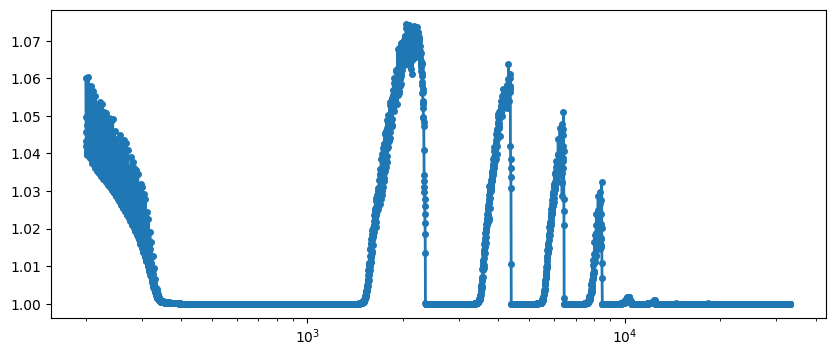

In [5]:
# Create plot
plt.figure(figsize=(10, 4))

# Plot CKD spectrum
plt.plot(opa.nu_bands, transit_ckd,
         'o-', label="CKD Method",
         markersize=4, linewidth=2, color='C0')

plt.xscale('log')